In [ ]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis s3fs fsspec pyproj

In [1]:
#libraries
import datetime as dt
import xarray as xr
import fsspec
import s3fs
import os.path
import matplotlib.pyplot as plt
import pandas as pd
from pyproj import Proj
     

In [2]:
def get_geo_data(sat='goes-west', lyr=2023, idyjl=1, product='ABI-L2-SSTF'):
    # arguments
    # sat      goes-east, goes-west
    # lyr      year
    # idyjl    day of year


    d = dt.datetime(lyr, 1, 1) + dt.timedelta(days=idyjl - 1)
    fs = s3fs.S3FileSystem(anon=True)

    # create strings for the year and Julian day
    imon, idym = d.month, d.day
    syr = str(lyr).zfill(4)
    sjdy = str(idyjl).zfill(3)
    smon = str(imon).zfill(2)
    sdym = str(idym).zfill(2)

    # use glob to list all the files in the directory
    if sat == 'goes-east':
        file_location, var = fs.glob(
            f's3://noaa-goes16/{product}/{syr}/{sjdy}/*/*.nc'
        ), 'SST'

    elif sat == 'goes-west':
        # GOES-18 is GOES-West for 2023+
        file_location, var = fs.glob(
            f's3://noaa-goes18/{product}/{syr}/{sjdy}/*/*.nc'
        ), 'SST'

    else:
        raise ValueError("sat must be 'goes-east' or 'goes-west'")

    if len(file_location) < 1:
        raise FileNotFoundError(
            f"No files found for {sat}, year={lyr}, day_of_year={idyjl}, product={product}"
        )

    # make a list of links to the file keys
    file_ob = [fs.open(file) for file in file_location]

    # open all the day's data
    ds = xr.open_mfdataset(
        file_ob,
        combine='nested',
        concat_dim='time',
        decode_times=False
    )

    # clean up coordinates
    if 't' in ds:
        ds = ds.rename({'t': 'time'})

    ds = ds.reset_coords()

    return ds

In [3]:
def make_goes_projection(ds):
    # Get the GOES projection metadata from the dataset
    proj_info = ds["goes_imager_projection"]

    # Satellite height above Earth
    sat_height = proj_info.attrs["perspective_point_height"]

    # Longitude where the satellite is centered
    lon_origin = proj_info.attrs["longitude_of_projection_origin"]

    # Direction GOES uses for scanning
    sweep = proj_info.attrs["sweep_angle_axis"]

    # Earth shape parameters used by the projection
    semi_major = proj_info.attrs["semi_major_axis"]
    semi_minor = proj_info.attrs["semi_minor_axis"]

    # Create the GOES map projection
    p = Proj(
        proj="geos",
        h=sat_height,
        lon_0=lon_origin,
        sweep=sweep,
        a=semi_major,
        b=semi_minor
    )

    # Return the projection object
    return p


def latlon_to_goes_xy(ds, lat, lon):
    #converts long/lat into GOES coordinates
    p = make_goes_projection(ds)

    sat_height = ds["goes_imager_projection"].attrs["perspective_point_height"]

    # pyproj expects lon, lat order
    x_m, y_m = p(lon, lat)

    # GOES x/y values are scan angles
    x = x_m / sat_height
    y = y_m / sat_height

    return x, y

In [4]:
coastal_points = {
    "San Diego": {      # Southern California
        "lat": 32.65,
        "lon": -117.35
    },
    "Monterey": {       # Central California
        "lat": 36.6002,
        "lon": -121.8947
    },
    "San Francisco": {  # Northern/Central California
        "lat": 37.7749,
        "lon": -122.4194
    },
    "Mendocino": {      # Northern California
        "lat": 39.3077,
        "lon": -123.7995
    }
}

In [5]:
#creates locations 
def make_coastal_boxes(ds, coastal_points, buffer=0.004):
    # Make a small GOES x/y box around each coastal city

    coastal_boxes = {}
    # Loop through each city and its coordinates
    for name, coords in coastal_points.items():
        # Convert city lat/lon to GOES x/y
        x, y = latlon_to_goes_xy(ds, coords["lat"], coords["lon"])

        coastal_boxes[name] = {
            # Original latitude
            "lat": coords["lat"],

            # Original longitude
            "lon": coords["lon"],

            # Center GOES x coordinate
            "x_center": x,

            # Center GOES y coordinate
            "y_center": y,

            # Small x range around the city
            "x": slice(x - buffer, x + buffer),

            # Capture small area around the city
            "x": slice(x - buffer, x + buffer),
            "y": slice(y + buffer, y - buffer)
        }

    return coastal_boxes

In [6]:
def daily_point_sst(ds, location_name, box):
    # Get average daily SST near one city
    subset = ds.sel(
        x=box["x"],
        y=box["y"]
    )

    # Keep only good quality SST pixels
    masked = subset["SST"].where(subset["DQF"] == 0)

    # Average over time and nearby pixels
    avg_k = masked.mean(
        dim=["time", "y", "x"],
        skipna=True
    ).compute()

    # Convert Kelvin to Fahrenheit
    avg_temp = float((avg_k - 273.15) * 9/5 + 32)

    return {
        "location": location_name,
        "lat": box["lat"],
        "lon": box["lon"],
        "x_center": box["x_center"],
        "y_center": box["y_center"],
        "sst_fahrenheit": avg_temp
    }

In [7]:
def get_days_for_months(year, months, step=5):
    dates = []

    for month in months:
        start = dt.date(year, month, 1)

        if month == 12:
            end = dt.date(year + 1, 1, 1)
        else:
            end = dt.date(year, month + 1, 1)

        current = start

        while current < end:
            dates.append(current)
            current += dt.timedelta(days=step)

    return dates


def date_to_day_of_year(date):
    return date.timetuple().tm_yday

In [8]:
def make_sst_dataset_for_points(lyr=2025, months=[7, 8], step=5, buffer=0.004):
    # Create a list of dates to load, every 5 days in July and August
    dates_to_load = get_days_for_months(lyr, months, step)

    all_rows = []

    # Loop through each date we want to load
    for date in dates_to_load:

        # Convert the date into GOES day-of-year format
        idyjl = date_to_day_of_year(date)

        # Print progress so we know which date is currently loading
        print(f"Loading {date} | day_of_year={idyjl}")

        try:
            # Load GOES-West SST data for this one day
            ds = get_geo_data(
                sat='goes-west',
                lyr=lyr,
                idyjl=idyjl,
                product='ABI-L2-SSTF'
            )

            # Convert each city lat/lon into a small GOES x/y box
            coastal_boxes = make_coastal_boxes(
                ds,
                coastal_points,
                buffer=buffer
            )

            # Loop through each city box
            for location_name, box in coastal_boxes.items():

                # Calculate average SST for that city on this date
                result = daily_point_sst(ds, location_name, box)

                # Add date information to the result row
                result["date"] = date.strftime("%Y-%m-%d")
                result["year"] = lyr
                result["month"] = date.month
                result["day"] = date.day
                result["day_of_year"] = idyjl

                all_rows.append(result)

           
            ds.close()

        except Exception as e:
    
            print(f"Skipping {date} because of error: {e}")

    return pd.DataFrame(all_rows)

In [12]:
#sst_df = make_sst_dataset_for_points(
#    lyr=2025,
#    months=[7, 8],
#    step=5,
#    buffer=0.004
#)

#sst_df

In [13]:
# sst_df.to_csv("california_coast_sst_july_august_2025.csv", index=False)

In [14]:
sst_df = pd.read_csv("california_coast_sst_july_august_2025.csv")
sst_df

,location,lat,lon,x_center,y_center,sst_fahrenheit,date,year,month,day,day_of_year
0,San Diego,32.7157,-117.1611,0.048875,0.092095,68.615013,2025-07-01,2025,7,1,182
1,Monterey,36.6002,-121.8947,0.035699,0.101275,53.527435,2025-07-01,2025,7,1,182
2,San Francisco,37.7749,-122.4194,0.033891,0.103859,53.632576,2025-07-01,2025,7,1,182
3,Mendocino,39.3077,-123.7995,0.030029,0.107178,53.929424,2025-07-01,2025,7,1,182
4,San Diego,32.7157,-117.1611,0.048875,0.092095,68.812935,2025-07-06,2025,7,6,187
5,Monterey,36.6002,-121.8947,0.035699,0.101275,57.444557,2025-07-06,2025,7,6,187
6,San Francisco,37.7749,-122.4194,0.033891,0.103859,56.347023,2025-07-06,2025,7,6,187
7,Mendocino,39.3077,-123.7995,0.030029,0.107178,56.525604,2025-07-06,2025,7,6,187
8,San Diego,32.7157,-117.1611,0.048875,0.092095,71.884384,2025-07-11,2025,7,11,192
9,Monterey,36.6002,-121.8947,0.035699,0.101275,55.553204,2025-07-11,2025,7,11,192


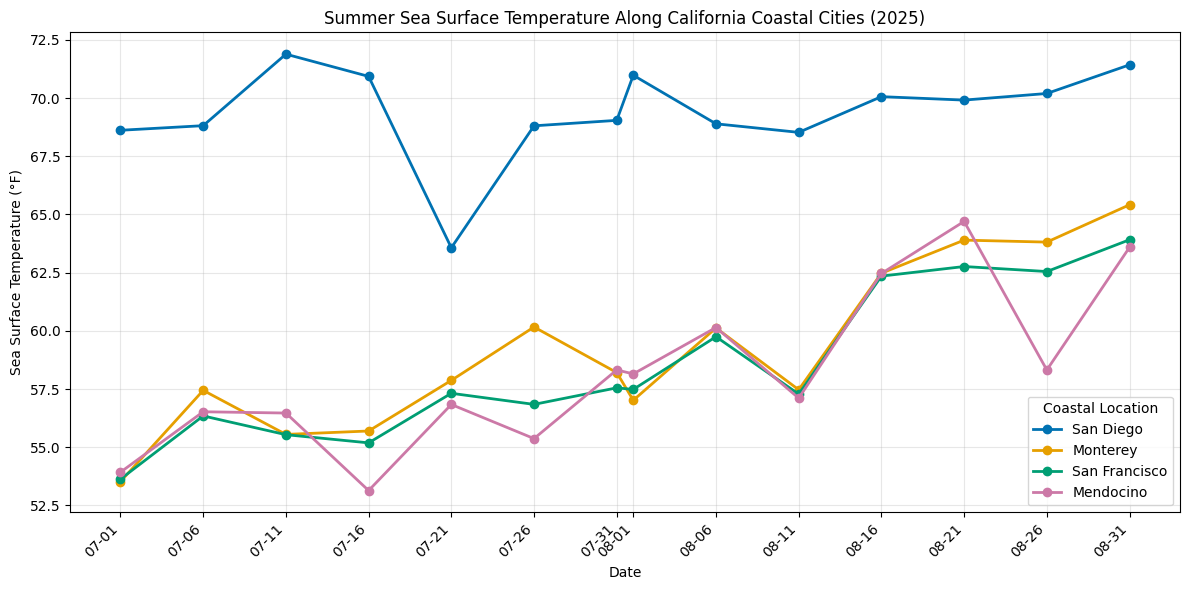

In [15]:
sst_df["date"] = pd.to_datetime(sst_df["date"])

plt.figure(figsize=(12, 6))

colors = {
    "San Diego": "#0072B2",      # blue
    "Monterey": "#E69F00",       # orange
    "San Francisco": "#009E73",  # green
    "Mendocino": "#CC79A7"       # purple
}

for location in ["San Diego", "Monterey", "San Francisco", "Mendocino"]:
    location_data = sst_df[sst_df["location"] == location]

    plt.plot(
        location_data["date"],
        location_data["sst_fahrenheit"],
        marker="o",
        linewidth=2,
        label=location,
        color= colors[location]
    )

plt.title("Summer Sea Surface Temperature Along California Coastal Cities (2025)")
plt.xlabel("Date")
plt.ylabel("Sea Surface Temperature (°F)")
plt.legend(title="Coastal Location")
plt.grid(True, alpha=0.3)
dates = sorted(sst_df["date"].unique())
plt.xticks(
    ticks=dates,
    labels=[pd.to_datetime(d).strftime("%m-%d") for d in dates],
    rotation=45,
    ha="right"
)
plt.tight_layout()
plt.show()

In [16]:
def plot_location_sst_map(ds, location_name, coastal_boxes):
    # Get the x/y box for this location
    box = coastal_boxes[location_name]

    # Subset GOES data to that city's small coastal box
    subset = ds.sel(
        x=box["x"],
        y=box["y"]
    )

    # Keep only good-quality SST pixels
    masked = subset["SST"].where(subset["DQF"] == 0)

    # Average across all times in the day
    mean_sst = masked.mean("time", skipna=True)

    # Convert Kelvin to Fahrenheit
    mean_sst_f = (mean_sst - 273.15) * 9/5 + 32

    # Plot the heatmap
    plt.figure(figsize=(6, 5))

    mean_sst_f.plot(
        cmap="inferno",
        vmin=50,
        vmax=75,
        cbar_kwargs={"label": "Sea Surface Temperature (°F)"}
    )

    plt.title(f"Daily Mean SST Near {location_name}")
    plt.xlabel("GOES x-coordinate")
    plt.ylabel("GOES y-coordinate")
    plt.tight_layout()
    plt.show()

In [18]:
ds = get_geo_data(
    sat="goes-west",
    lyr=2025,
    idyjl=210, #July 29, 2025
    product="ABI-L2-SSTF"
)

coastal_boxes = make_coastal_boxes(
    ds,
    coastal_points,
    buffer=0.008
)

/var/folders/g5/7q0ynznx5hs03d9_7j1h1qbc0000gn/T/ipykernel_81029/2195258461.py:51: UserWarning: rename 't' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({'t': 'time'})


In [26]:
coastal_boxes

{'San Diego': {'lat': 32.65,
  'lon': -117.35,
  'x_center': np.float64(0.04847747545435037),
  'y_center': np.float64(0.09195516470419485),
  'x': slice(np.float64(0.04047747545435037), np.float64(0.05647747545435037), None),
  'y': slice(np.float64(0.09995516470419485), np.float64(0.08395516470419484), None)},
 'Monterey': {'lat': 36.6002,
  'lon': -121.8947,
  'x_center': np.float64(0.035699380750764745),
  'y_center': np.float64(0.10127520169631013),
  'x': slice(np.float64(0.027699380750764745), np.float64(0.043699380750764745), None),
  'y': slice(np.float64(0.10927520169631014), np.float64(0.09327520169631012), None)},
 'San Francisco': {'lat': 37.7749,
  'lon': -122.4194,
  'x_center': np.float64(0.033890532495963764),
  'y_center': np.float64(0.10385871328489547),
  'x': slice(np.float64(0.025890532495963764), np.float64(0.041890532495963764), None),
  'y': slice(np.float64(0.11185871328489547), np.float64(0.09585871328489548), None)},
 'Mendocino': {'lat': 39.3077,
  'lon': -

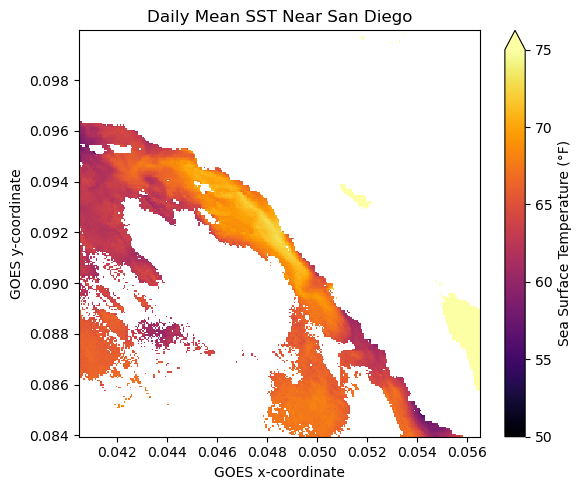

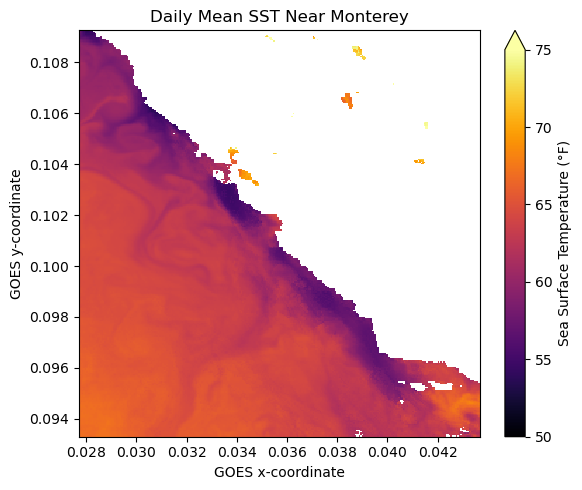

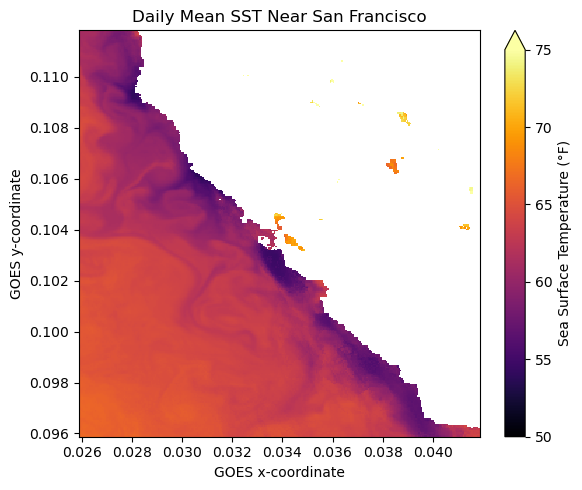

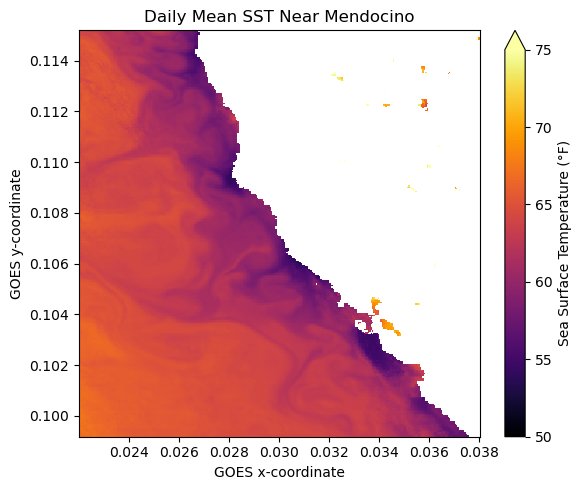

In [ ]:
plot_location_sst_map(ds, "San Diego", coastal_boxes)
plot_location_sst_map(ds, "Monterey", coastal_boxes)
plot_location_sst_map(ds, "San Francisco", coastal_boxes)
plot_location_sst_map(ds, "Mendocino", coastal_boxes)

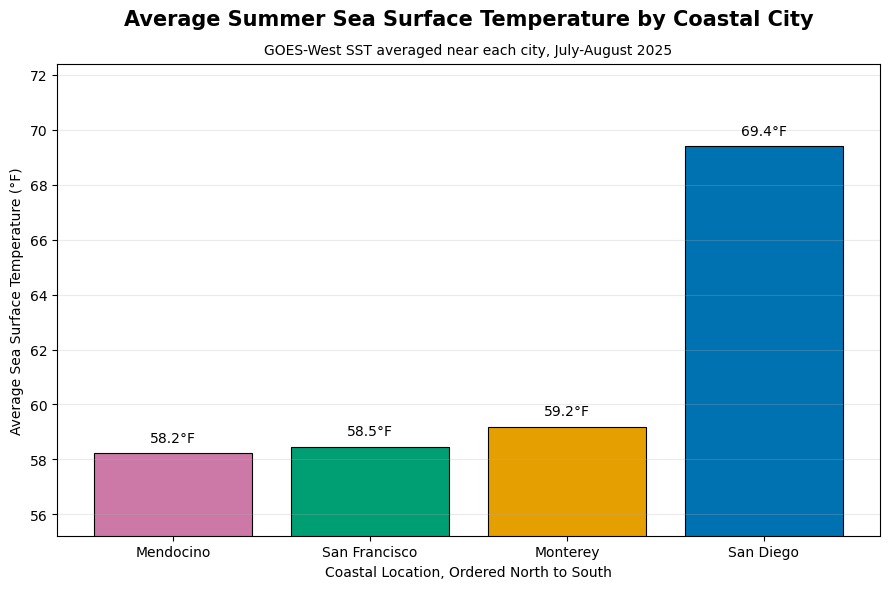

In [ ]:
avg_sst = (
    sst_df
    .groupby("location")["sst_fahrenheit"]
    .mean()
    .reset_index()
)

location_order = ["Mendocino", "San Francisco", "Monterey", "San Diego"]

avg_sst["location"] = pd.Categorical(
    avg_sst["location"],
    categories=location_order,
    ordered=True
)

avg_sst = avg_sst.sort_values("location")

colors = ["#CC79A7", "#009E73", "#E69F00", "#0072B2"]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    avg_sst["location"],
    avg_sst["sst_fahrenheit"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Average Summer Sea Surface Temperature by Coastal City",
    fontsize=15,
    fontweight="bold",
    pad=28
)

ax.text(
    0.5,
    1.02,
    "GOES-West SST averaged near each city, July-August 2025",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.set_xlabel("Coastal Location, Ordered North to South")
ax.set_ylabel("Average Sea Surface Temperature (°F)")

ax.set_ylim(
    avg_sst["sst_fahrenheit"].min() - 3,
    avg_sst["sst_fahrenheit"].max() + 3
)

ax.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    ax.text(    
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f}°F",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

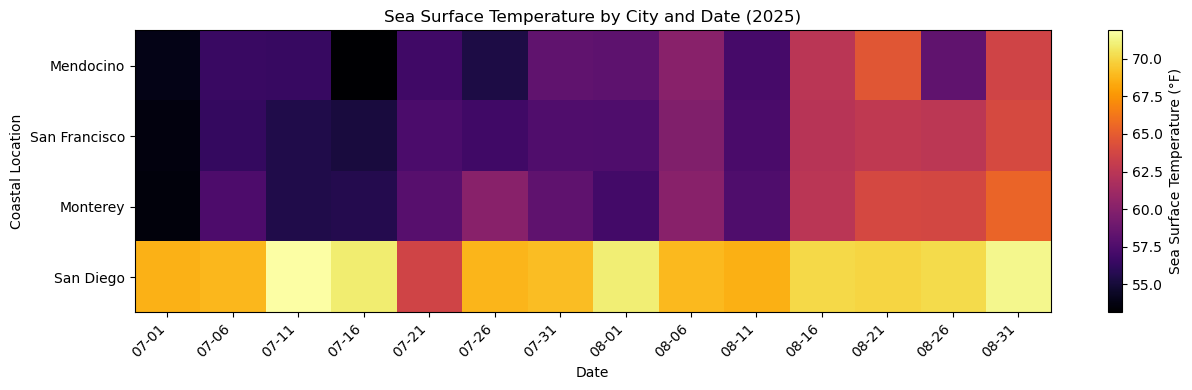

In [52]:
heatmap_data = sst_df.pivot(
    index="location",
    columns="date",
    values="sst_fahrenheit"
)

location_order = ["Mendocino", "San Francisco", "Monterey", "San Diego"]
heatmap_data = heatmap_data.loc[location_order]

plt.figure(figsize=(13, 4))

plt.imshow(
    heatmap_data,
    aspect="auto",
    cmap="inferno"
)

plt.colorbar(label="Sea Surface Temperature (°F)")

plt.title("Sea Surface Temperature by City and Date (2025)")
plt.xlabel("Date")
plt.ylabel("Coastal Location")

plt.xticks(
    ticks=range(len(heatmap_data.columns)),
    labels=[pd.to_datetime(d).strftime("%m-%d") for d in heatmap_data.columns],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=range(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.tight_layout()
plt.show()

C:\Users\nicho\AppData\Local\Temp\ipykernel_26872\4157497723.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


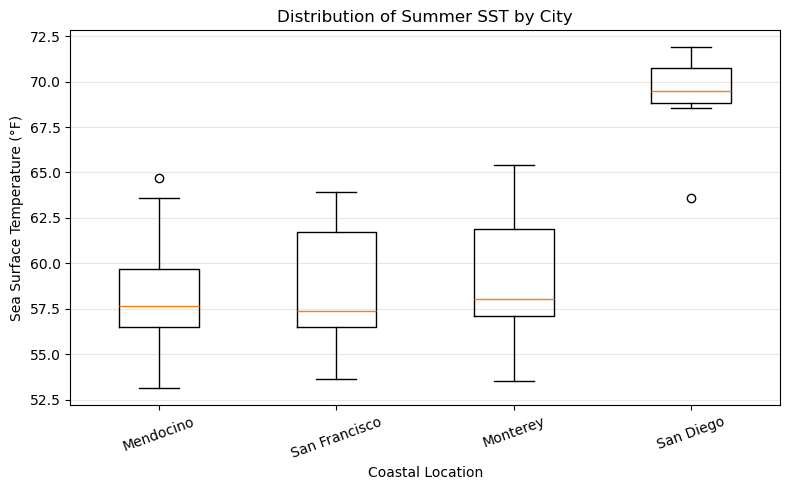

In [53]:
location_order = ["Mendocino", "San Francisco", "Monterey", "San Diego"]

box_data = [
    sst_df[sst_df["location"] == location]["sst_fahrenheit"]
    for location in location_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    box_data,
    labels=location_order
)

plt.title("Distribution of Summer SST by City")
plt.xlabel("Coastal Location")
plt.ylabel("Sea Surface Temperature (°F)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

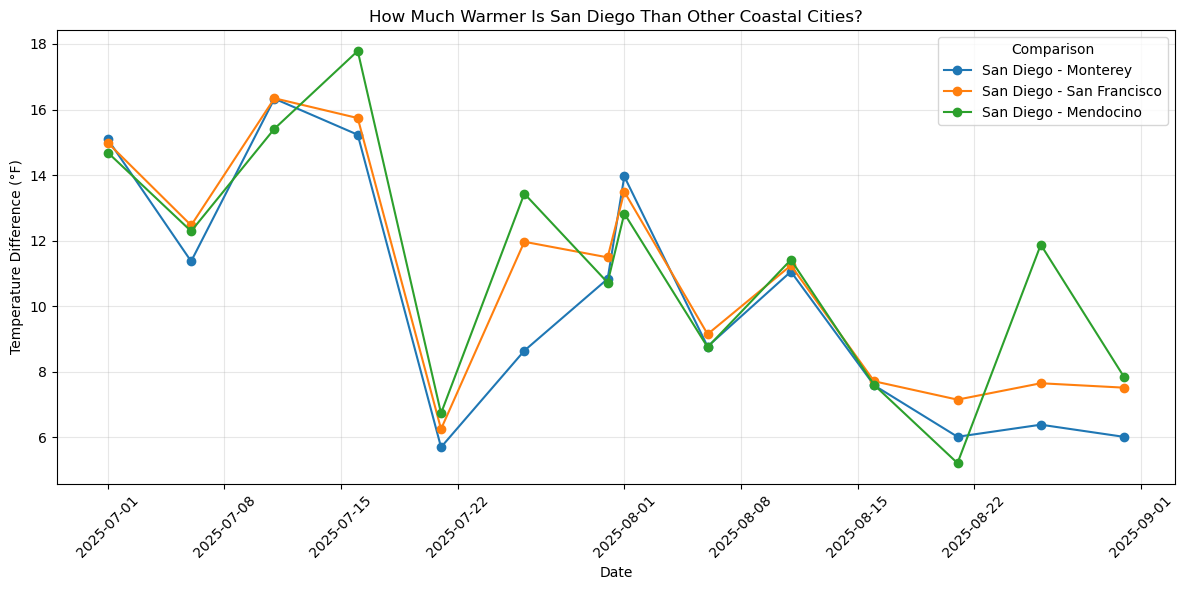

In [54]:
wide_df = sst_df.pivot(
    index="date",
    columns="location",
    values="sst_fahrenheit"
).reset_index()

wide_df["San Diego - Monterey"] = wide_df["San Diego"] - wide_df["Monterey"]
wide_df["San Diego - San Francisco"] = wide_df["San Diego"] - wide_df["San Francisco"]
wide_df["San Diego - Mendocino"] = wide_df["San Diego"] - wide_df["Mendocino"]

plt.figure(figsize=(12, 6))

gap_cols = [
    "San Diego - Monterey",
    "San Diego - San Francisco",
    "San Diego - Mendocino"
]

for col in gap_cols:
    plt.plot(
        wide_df["date"],
        wide_df[col],
        marker="o",
        label=col
    )

plt.title("How Much Warmer Is San Diego Than Other Coastal Cities?")
plt.xlabel("Date")
plt.ylabel("Temperature Difference (°F)")
plt.legend(title="Comparison")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
import pyproj

def get_goes_xy_bounds(bbox, ds):
    """
    Translates a Lat/Lon bounding box into GOES x/y radian coordinates.
    bbox format: [min_lon, max_lon, min_lat, max_lat]
    """
    min_lon, max_lon, min_lat, max_lat = bbox
    
    # Extract GOES projection parameters directly from the dataset
    proj_info = ds.goes_imager_projection
    sat_height = proj_info.perspective_point_height
    sat_lon = proj_info.longitude_of_projection_origin
    sweep = proj_info.sweep_angle_axis
    
    # Create the pyproj transformation object
    p = pyproj.Proj(proj='geos', h=sat_height, lon_0=sat_lon, sweep=sweep)
    
    # Transform Lat/Lon to GOES projection meters
    x_min_m, y_min_m = p(min_lon, min_lat)
    x_max_m, y_max_m = p(max_lon, max_lat)
    
    # Convert meters to GOES radians (meters / satellite height)
    x_min_rad, x_max_rad = sorted([x_min_m / sat_height, x_max_m / sat_height])
    
    # GOES y-coordinates scan top-to-bottom, so y_max_rad is actually North
    y_min_rad, y_max_rad = sorted([y_min_m / sat_height, y_max_m / sat_height])
    
    return x_min_rad, x_max_rad, y_min_rad, y_max_rad

In [23]:
import datetime as dt
import s3fs
import xarray as xr

def get_geo_data_updated(sat='goes-west', lyr=2023, idyjl=1, product='ABI-L2-SSTF', bbox=None):
    # arguments
    # sat      goes-east, goes-west
    # lyr      year
    # idyjl    day of year
    # bbox     [min_lon, max_lon, min_lat, max_lat] (optional)

    d = dt.datetime(lyr, 1, 1) + dt.timedelta(days=idyjl - 1)
    fs = s3fs.S3FileSystem(anon=True)

    imon, idym = d.month, d.day
    syr = str(lyr).zfill(4)
    sjdy = str(idyjl).zfill(3)

    if sat == 'goes-east':
        file_location = fs.glob(f's3://noaa-goes16/{product}/{syr}/{sjdy}/*/*.nc')
    elif sat == 'goes-west':
        file_location = fs.glob(f's3://noaa-goes18/{product}/{syr}/{sjdy}/*/*.nc')
    else:
        raise ValueError("sat must be 'goes-east' or 'goes-west'")

    if len(file_location) < 1:
        raise FileNotFoundError(f"No files found for {sat}, year={lyr}, day_of_year={idyjl}")

    # open all the day's data
    file_ob = [fs.open(file) for file in file_location]
    ds = xr.open_mfdataset(
        file_ob,
        combine='nested',
        concat_dim='time',
        decode_times=False
    )

    if 't' in ds:
        ds = ds.rename({'t': 'time'})
    ds = ds.reset_coords()

    # --- NEW SPATIAL SUBSETTING LOGIC ---
    if bbox:
        # Get the bounding box in GOES radians
        x_min, x_max, y_min, y_max = get_goes_xy_bounds(bbox, ds)
        
        # Slice the dataset. 
        # Note: GOES 'y' coordinates go from positive (North) to negative (South).
        # We must slice from y_max to y_min for xarray to understand the direction.
        ds = ds.sel(x=slice(x_min, x_max), y=slice(y_max, y_min))
    # ------------------------------------

    return ds

In [ ]:
import datetime as dt
import pandas as pd
import numpy as np
import pyproj

# 1. Define your regions (same as before)
regions = {
    "San Diego": [-118.5, -116.5, 32.0, 33.5],
    "Monterey": [-123.0, -121.0, 35.5, 37.5],
    "San Francisco": [-123.5, -121.5, 37.0, 38.5],
    "Mendocino": [-125.0, -123.0, 38.5, 40.0]
}

all_regional_data = []
target_year = 2025

# 2. Define your time range (e.g., July 1st to July 11th)
start_day = 182
end_day = 212

# 3. Loop through each day
for day_of_year in range(start_day, end_day + 1, 3):
    
    # Calculate the readable date string for D3 (e.g., "2025-07-01")
    date_obj = dt.datetime(target_year, 1, 1) + dt.timedelta(days=day_of_year - 1)
    date_string = date_obj.strftime("%Y-%m-%d")
    
    print(f"\n--- Fetching data for {date_string} ---")
    
    # 4. Loop through each region for the current day
    for region_name, bbox in regions.items():
        print(f"Processing {region_name}...")
        
        try:
            # Pass the dynamic day_of_year into your function
            ds = get_geo_data(sat='goes-west', lyr=target_year, idyjl=day_of_year, product='ABI-L2-SSTF', bbox=bbox)
            
            proj_info = ds.goes_imager_projection
            sat_height = proj_info.perspective_point_height
            sat_lon = proj_info.longitude_of_projection_origin
            sweep = proj_info.sweep_angle_axis
            
            x_meters = ds.x.values * sat_height
            y_meters = ds.y.values * sat_height
            xx, yy = np.meshgrid(x_meters, y_meters)
            
            p = pyproj.Proj(proj='geos', h=sat_height, lon_0=sat_lon, sweep=sweep)
            lons, lats = p(xx, yy, inverse=True)
            
            # Collapse the time dimension by taking the daily average
            sst_data = ds['SST'].mean(dim='time', skipna=True).values
            
            df_region = pd.DataFrame({
                'region': region_name,
                'date': date_string,     # Attaches the dynamic date to every row
                'lat': lats.flatten(),
                'lon': lons.flatten(),
                'sst_fahrenheit': sst_data.flatten()
            })
            
            # Drop empty pixels (land/clouds)
            df_region = df_region.dropna(subset=['sst_fahrenheit'])
            all_regional_data.append(df_region)
            print(f"   -> Found {len(df_region)} valid water pixels.")
            
        except FileNotFoundError:
            print(f"   -> WARNING: No satellite data found for {date_string}. Skipping.")
        except Exception as e:
            print(f"   -> ERROR processing {region_name} on {date_string}: {e}")

# 5. Combine and export the multi-day dataset
print("\nCompiling final dataset...")
final_df = pd.concat(all_regional_data, ignore_index=True)

# Sort chronologically just to be safe
final_df = final_df.sort_values(by=['date', 'region'])

final_df.to_csv("regional_coastal_sst.csv", index=False)
print("Time-series extraction complete! Saved to regional_coastal_sst.csv")


--- Fetching data for 2025-07-01 ---
Processing San Diego...
